In [ ]:
# @title
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

try:
    ee.Initialize(project='replicating-paper')
    print("Google Earth Engine Initialized successfully.")
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='replicating-paper')

In [ ]:
# @title

REGIONS = {
    'sanjay_van': {
        'name': 'Sanjay Van, Delhi',

        'bounds': [77.17, 28.52, 77.18, 28.54],
        'description': 'Urban Dry Deciduous / Scrub'
    },
    'sundarbans': {
        'name': 'Sundarbans Mangroves',
        'bounds': [88.80, 21.80, 89.00, 22.00],
        'description': 'Coastal Mangrove / Tidal'
    },
    'western_ghats': {
        'name': 'Western Ghats (Nilgiris)',
        'bounds': [76.50, 11.30, 76.70, 11.50],
        'description': 'Tropical Evergreen / Montane'
    },
    'himalayas': {
        'name': 'Great Himalayan National Park',
        'bounds': [77.50, 31.70, 77.70, 31.90],
        'description': 'Sub-alpine / Coniferous'
    }
}

CURRENT_REGION_KEY = 'sanjay_van'

roi_info = REGIONS[CURRENT_REGION_KEY]
roi = ee.Geometry.Rectangle(roi_info['bounds'])
print(f"Analysis Focus: {roi_info['name']} ({roi_info['description']})")

Analysis Focus: Sanjay Van, Delhi (Urban Dry Deciduous / Scrub)


In [ ]:
# @title
import pandas as pd

data_inventory = [
    {
        "Dataset": "Sentinel-2 (Harmonized)",
        "GEE_ID": "COPERNICUS/S2_SR_HARMONIZED",
        "Resolution": "10m",
        "Purpose": "Primary Phenology (NDVI, NIRv), Seasonal Cycles",
        "Temporal Range": "2018 - 2024"
    },
    {
        "Dataset": "Dynamic World V1",
        "GEE_ID": "GOOGLE/DYNAMICWORLD/V1",
        "Resolution": "10m",
        "Purpose": "Forest Persistence (Probability of tree cover over time)",
        "Temporal Range": "2018 - 2024"
    },

    {
        "Dataset": "Global Canopy Height (ETH)",
        "GEE_ID": "users/nlang/ETH_GlobalCanopyHeight_2020_10m_v1",
        "Resolution": "10m",
        "Purpose": "Vertical Structure (Tree Height in meters)",
        "Temporal Range": "2020 (Baseline)"
    },
    {
        "Dataset": "Sentinel-1 SAR (C-Band)",
        "GEE_ID": "COPERNICUS/S1_GRD",
        "Resolution": "10m",
        "Purpose": "Canopy Texture & Leaf Volume (All-weather structure)",
        "Temporal Range": "2023 - 2024"
    },
    {
        "Dataset": "ALOS PALSAR-2 (L-Band)",
        "GEE_ID": "JAXA/ALOS/PALSAR/YEARLY/SAR",
        "Resolution": "25m",
        "Purpose": "Woody Biomass (Penetrates canopy to see trunks/stems)",
        "Temporal Range": "2015 - 2024"
    },

    {
        "Dataset": "NASADEM (SRTM)",
        "GEE_ID": "NASA/NASADEM_HGT/001",
        "Resolution": "30m",
        "Purpose": "Topography (Elevation, Slope, Aspect)",
        "Temporal Range": "2000 (Static)"
    },
    {
        "Dataset": "WorldClim Bioclim V1",
        "GEE_ID": "WORLDCLIM/V1/BIO",
        "Resolution": "1km",
        "Purpose": "Climate Limits (Temperature/Rainfall biological ranges)",
        "Temporal Range": "1960-1990 (Climatic Baseline)"
    },
    {
        "Dataset": "CHIRPS Pentad",
        "GEE_ID": "UCSB-CHG/CHIRPS/PENTAD",
        "Resolution": "5km",
        "Purpose": "Water Stress (Recent Drought/Wetness anomalies)",
        "Temporal Range": "2000 - 2024"
    },
    {
        "Dataset": "OpenLandMap Soil",
        "GEE_ID": "OpenLandMap/SOL/SOL_CLAY-WFRACTION_USDA-3A1A1A_M/v02",
        "Resolution": "250m",
        "Purpose": "Edaphic Conditions (Soil Texture/Clay Content)",
        "Temporal Range": "1950 - 2017 (Static)"
    },
    {
        "Dataset": "JRC Global Surface Water",
        "GEE_ID": "JRC/GSW1_4/GlobalSurfaceWater",
        "Resolution": "30m",
        "Purpose": "Hydrology (Seasonality: Is it a lake or a seasonal swamp?)",
        "Temporal Range": "1984 - 2021"
    },

    {
        "Dataset": "VIIRS Nighttime Lights",
        "GEE_ID": "NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG",
        "Resolution": "460m",
        "Purpose": "Human Pressure (Urbanization/Light Pollution)",
        "Temporal Range": "2014 - 2024"
    },
    {
        "Dataset": "Hansen Global Forest Change",
        "GEE_ID": "UMD/hansen/global_forest_change_2023_v1_11",
        "Resolution": "30m",
        "Purpose": "Forest Loss History (Years since loss)",
        "Temporal Range": "2000 - 2023"
    },
    {
        "Dataset": "MODIS Burned Area",
        "GEE_ID": "MODIS/061/MCD64A1",
        "Resolution": "500m",
        "Purpose": "Fire History (Years since last burn)",
        "Temporal Range": "2001 - 2023"
    }
]

df_inventory = pd.DataFrame(data_inventory)

print(f"--- Definitive Data Inventory: {len(df_inventory)} Sources ---")
display(df_inventory.style.set_properties(**{'text-align': 'left'}).set_table_styles([
    dict(selector='th', props=[('text-align', 'left')])
]))

--- Definitive Data Inventory: 13 Sources ---


,Dataset,GEE_ID,Resolution,Purpose,Temporal Range
0,Sentinel-2 (Harmonized),COPERNICUS/S2_SR_HARMONIZED,10m,"Primary Phenology (NDVI, NIRv), Seasonal Cycles",2018 - 2024
1,Dynamic World V1,GOOGLE/DYNAMICWORLD/V1,10m,Forest Persistence (Probability of tree cover over time),2018 - 2024
2,Global Canopy Height (ETH),users/nlang/ETH_GlobalCanopyHeight_2020_10m_v1,10m,Vertical Structure (Tree Height in meters),2020 (Baseline)
3,Sentinel-1 SAR (C-Band),COPERNICUS/S1_GRD,10m,Canopy Texture & Leaf Volume (All-weather structure),2023 - 2024
4,ALOS PALSAR-2 (L-Band),JAXA/ALOS/PALSAR/YEARLY/SAR,25m,Woody Biomass (Penetrates canopy to see trunks/stems),2015 - 2024
5,NASADEM (SRTM),NASA/NASADEM_HGT/001,30m,"Topography (Elevation, Slope, Aspect)",2000 (Static)
6,WorldClim Bioclim V1,WORLDCLIM/V1/BIO,1km,Climate Limits (Temperature/Rainfall biological ranges),1960-1990 (Climatic Baseline)
7,CHIRPS Pentad,UCSB-CHG/CHIRPS/PENTAD,5km,Water Stress (Recent Drought/Wetness anomalies),2000 - 2024
8,OpenLandMap Soil,OpenLandMap/SOL/SOL_CLAY-WFRACTION_USDA-3A1A1A_M/v02,250m,Edaphic Conditions (Soil Texture/Clay Content),1950 - 2017 (Static)
9,JRC Global Surface Water,JRC/GSW1_4/GlobalSurfaceWater,30m,Hydrology (Seasonality: Is it a lake or a seasonal swamp?),1984 - 2021


In [ ]:

def get_harmonic_features(region, start_year, end_year):

    s2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
        .filterBounds(region) \
        .filterDate(f'{start_year}-01-01', f'{end_year}-12-31') \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))

    def add_indices_and_time(img):
        ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')

        nirv = ndvi.multiply(img.select('B8').divide(10000)).rename('NIRv')

        time_radians = img.date().difference(ee.Date(f'{start_year}-01-01'), 'year') \
            .multiply(2 * 3.1415926535)
        time_band = ee.Image(time_radians).rename('t').toFloat()

        constant = ee.Image.constant(1).rename('constant')

        cos = time_band.cos().rename('cos')
        sin = time_band.sin().rename('sin')

        return img.addBands([ndvi, nirv, time_band, constant, cos, sin])

    with_metrics = s2.map(add_indices_and_time)

    def fit_harmonics(collection, dependent_var):
        independents = ['constant', 't', 'cos', 'sin']

        trend = collection.select(independents + [dependent_var]) \
            .reduce(ee.Reducer.linearRegression(4, 1))

        coeffs = trend.select('coefficients') \
            .arrayFlatten([[f'{dependent_var}_mean', f'{dependent_var}_trend',
                            f'{dependent_var}_beta_cos', f'{dependent_var}_beta_sin'], ['dummy']])

        clean_names = [f'{dependent_var}_mean', f'{dependent_var}_trend',
                       f'{dependent_var}_beta_cos', f'{dependent_var}_beta_sin']
        dummy_names = [f'{name}_dummy' for name in clean_names]

        coeffs = coeffs.select(dummy_names, clean_names)

        amp = coeffs.select(f'{dependent_var}_beta_cos').hypot(coeffs.select(f'{dependent_var}_beta_sin')) \
            .rename(f'{dependent_var}_Amp')

        phase = coeffs.select(f'{dependent_var}_beta_sin').atan2(coeffs.select(f'{dependent_var}_beta_cos')) \
            .rename(f'{dependent_var}_Phase')

        simple_mean = collection.select(dependent_var).mean().rename(f'{dependent_var}_Simple_Mean')

        return coeffs.addBands([amp, phase, simple_mean])


    ndvi_harmonics = fit_harmonics(with_metrics, 'NDVI')
    nirv_harmonics = fit_harmonics(with_metrics, 'NIRv')

    return ndvi_harmonics.addBands(nirv_harmonics)

def get_dynamic_world_stats(region, start_year, end_year):

    dw = ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1") \
        .filterBounds(region) \
        .filterDate(f'{start_year}-01-01', f'{end_year}-12-31')

    tree_prob = dw.select('trees').mean().rename('Tree_Prob_Mean')


    tree_std = dw.select('trees').reduce(ee.Reducer.stdDev()).rename('Tree_Prob_StdDev')

    dominant_class = dw.select('label').mode().rename('Dominant_Land_Class')

    return tree_prob.addBands([tree_std, dominant_class]).clip(region)

print("Feature Engineering (Harmonics & DW Stability) functions ready.")

Feature Engineering (Harmonics & DW Stability) functions ready.


In [ ]:
# @title
import datetime
def get_structure_and_disturbance(region):

    current_year = datetime.datetime.now().year

    HANSEN_START_YEAR = 2000
    MODIS_START_YEAR = 2001


    loss_stability_cap = (current_year - HANSEN_START_YEAR) + 1
    fire_stability_cap = (current_year - MODIS_START_YEAR) + 1

    print(f"   Dynamic Stability Caps -> Loss: {loss_stability_cap} years (since {HANSEN_START_YEAR}), Fire: {fire_stability_cap} years (since {MODIS_START_YEAR})")


    ch = ee.Image("users/nlang/ETH_GlobalCanopyHeight_2020_10m_v1") \
        .clip(region) \
        .select('b1').rename('Canopy_Height') \
        .unmask(0)


    ch_texture = ch.reduceNeighborhood(
        reducer=ee.Reducer.stdDev(),
        kernel=ee.Kernel.circle(90, 'meters')
    ).rename('Canopy_Texture')


    s1 = ee.ImageCollection("COPERNICUS/S1_GRD") \
        .filterBounds(region) \
        .filterDate('2023-01-01', '2024-01-01') \
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
        .filter(ee.Filter.eq('instrumentMode', 'IW'))

    s1_vh = s1.select('VH').mean().rename('S1_VH_Mean').clip(region)


    palsar = ee.ImageCollection("JAXA/ALOS/PALSAR/YEARLY/SAR") \
        .filterDate('2020-01-01', '2024-01-01') \
        .filterBounds(region) \
        .first()

    palsar_hv = palsar.select('HV').rename('PALSAR_HV').clip(region)


    gfc = ee.Image("UMD/hansen/global_forest_change_2023_v1_11").clip(region)
    loss_year = gfc.select('lossyear')



    loss_event_year = loss_year.add(2000)


    years_ago_loss = ee.Image.constant(current_year).subtract(loss_event_year)


    years_since_loss = years_ago_loss \
        .updateMask(loss_year.gt(0)) \
        .rename('Years_Since_Loss') \
        .unmask(loss_stability_cap)


    fire = ee.ImageCollection("MODIS/061/MCD64A1") \
        .filterBounds(region) \
        .filterDate('2001-01-01', '2023-12-31') \
        .select('BurnDate')

    def get_fire_year(img):
        return ee.Image.constant(img.date().get('year')).updateMask(img.gt(0)).rename('Fire_Year').toInt()


    last_fire_year = fire.map(get_fire_year).max().clip(region)


    years_ago_fire = ee.Image.constant(current_year).subtract(last_fire_year)


    years_since_fire = years_ago_fire \
        .rename('Years_Since_Fire') \
        .unmask(fire_stability_cap)



    structure_stack = ch.addBands([
        ch_texture,
        s1_vh,
        palsar_hv,
        years_since_loss,
        years_since_fire
    ])

    return structure_stack

print("Feature Engineering (Structure & Disturbance) function defined.")

Feature Engineering (Structure & Disturbance) function defined.


In [ ]:
# @title

def get_environmental_context(region, start_year, end_year):


    nasa_dem = ee.Image("NASA/NASADEM_HGT/001").clip(region)
    elevation = nasa_dem.select('elevation').rename('Elevation')
    slope = ee.Terrain.slope(elevation).rename('Slope')
    aspect = ee.Terrain.aspect(elevation).rename('Aspect')


    rad = aspect.multiply(3.1415926535).divide(180)
    northness = rad.cos().rename('Northness')
    eastness = rad.sin().rename('Eastness')

    terrain_stack = elevation.addBands([slope, northness, eastness])


    worldclim = ee.Image("WORLDCLIM/V1/BIO").clip(region)
    climate_bio = worldclim.select(['bio01', 'bio12']).rename(['Mean_Temp_Bio01', 'Annual_Precip_Bio12'])


    chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/PENTAD").filterBounds(region)

    baseline_rain = chirps.filterDate('2000-01-01', '2020-12-31').select('precipitation').mean()
    recent_rain = chirps.filterDate(f'{start_year}-01-01', f'{end_year}-12-31').select('precipitation').mean()

    rainfall_anomaly = recent_rain.subtract(baseline_rain).divide(baseline_rain) \
        .rename('Rainfall_Anomaly')


    soil_clay = ee.Image("OpenLandMap/SOL/SOL_CLAY-WFRACTION_USDA-3A1A1A_M/v02") \
        .select('b0').clip(region).rename('Soil_Clay_Surface')


    jrc_water = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").clip(region)
    water_seasonality = jrc_water.select('seasonality').unmask(0).rename('Water_Seasonality')


    viirs = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG") \
        .filterBounds(region) \
        .filterDate(f'{start_year}-01-01', f'{end_year}-12-31') \
        .select('avg_rad').mean().clip(region) \
        .rename('Night_Lights')


    context_stack = terrain_stack \
        .addBands(climate_bio) \
        .addBands(rainfall_anomaly) \
        .addBands(soil_clay) \
        .addBands(water_seasonality) \
        .addBands(viirs)

    return context_stack

print("Feature Engineering Part 3 (Environmental Context) defined.")

Feature Engineering Part 3 (Environmental Context) defined.


In [ ]:
# @title

print("1. Calculating Harmonics & Phenology (Sentinel-2)...")
phenology_stack = get_harmonic_features(roi, 2020, 2023)

print("2. Calculating Forest Stability (Dynamic World)...")
stability_stack = get_dynamic_world_stats(roi, 2020, 2023)

print("3. Calculating Physical Structure (Lidar/Radar/Fire)...")
structure_stack = get_structure_and_disturbance(roi)

print("4. Calculating Environmental Context (Terrain/Climate)...")
context_stack = get_environmental_context(region=roi, start_year=2020, end_year=2023)

print("5. Merging into MASTER STACK...")

master_stack = phenology_stack \
    .addBands(stability_stack) \
    .addBands(structure_stack) \
    .addBands(context_stack) \
    .clip(roi) \
    .toFloat()

print("Success! Master Stack built.")
print(f"Total Bands: {len(master_stack.bandNames().getInfo())}")
print("Band Names:", master_stack.bandNames().getInfo())

1. Calculating Harmonics & Phenology (Sentinel-2)...
2. Calculating Forest Stability (Dynamic World)...
3. Calculating Physical Structure (Lidar/Radar/Fire)...
   Dynamic Stability Caps -> Loss: 27 years (since 2000), Fire: 26 years (since 2001)
4. Calculating Environmental Context (Terrain/Climate)...
5. Merging into MASTER STACK...
Success! Master Stack built.


/usr/local/lib/python3.12/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for UMD/hansen/global_forest_change_2023_v1_11! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/UMD_hansen_global_forest_change_2023_v1_11

  warnings.warn(warning, category=DeprecationWarning)


Total Bands: 33
Band Names: ['NDVI_mean', 'NDVI_trend', 'NDVI_beta_cos', 'NDVI_beta_sin', 'NDVI_Amp', 'NDVI_Phase', 'NDVI_Simple_Mean', 'NIRv_mean', 'NIRv_trend', 'NIRv_beta_cos', 'NIRv_beta_sin', 'NIRv_Amp', 'NIRv_Phase', 'NIRv_Simple_Mean', 'Tree_Prob_Mean', 'Tree_Prob_StdDev', 'Dominant_Land_Class', 'Canopy_Height', 'Canopy_Texture', 'S1_VH_Mean', 'PALSAR_HV', 'Years_Since_Loss', 'Years_Since_Fire', 'Elevation', 'Slope', 'Northness', 'Eastness', 'Mean_Temp_Bio01', 'Annual_Precip_Bio12', 'Rainfall_Anomaly', 'Soil_Clay_Surface', 'Water_Seasonality', 'Night_Lights']


In [ ]:
# @title

import pandas as pd

print("Sampling 5 RANDOM pixels from the ROI to inspect feature vectors...")




debug_samples = master_stack.sample(
    region=roi,
    scale=10,
    numPixels=5,
    geometries=True
).getInfo()


features = [f['properties'] for f in debug_samples['features']]
df_debug = pd.DataFrame(features)


if df_debug.empty:
    print("WARNING: No data found. Check if your ROI has valid satellite coverage.")
else:


    print("\n--- FEATURE VECTORS (5 Random Pixels) ---")
    display(df_debug.T.style.set_properties(**{'text-align': 'right'}))

    print("\nInterpretation Check:")
    print("- NDVI_Mean should be between 0.0 and 1.0")
    print("- Elevation should be in meters (e.g., 200-300 for Delhi)")
    print("- Tree_Prob_Mean is 0.0-1.0 (Higher = More likely Forest)")

Sampling 5 RANDOM pixels from the ROI to inspect feature vectors...

--- FEATURE VECTORS (5 Random Pixels) ---


,0,1,2,3,4
Annual_Precip_Bio12,531.000000,521.000000,531.000000,521.000000,549.000000
Canopy_Height,7.000000,0.000000,0.000000,0.000000,11.000000
Canopy_Texture,3.299186,0.065371,1.329321,1.436114,3.825115
Dominant_Land_Class,1.000000,6.000000,6.000000,6.000000,1.000000
Eastness,0.000000,0.915543,0.000000,0.959687,0.915568
Elevation,262.000000,259.000000,267.000000,261.000000,245.000000
Mean_Temp_Bio01,250.000000,250.000000,249.000000,250.000000,250.000000
NDVI_Amp,0.050618,0.019893,0.007451,0.021266,0.059207
NDVI_Phase,-2.888382,-0.497737,2.382230,-1.187832,2.651650
NDVI_Simple_Mean,0.672370,0.019538,0.054655,0.062417,0.620373



Interpretation Check:
- NDVI_Mean should be between 0.0 and 1.0
- Elevation should be in meters (e.g., 200-300 for Delhi)
- Tree_Prob_Mean is 0.0-1.0 (Higher = More likely Forest)


Sampling 2,000 pixels to inspect distributions for ALL bands...
Plotting histograms for 33 features...


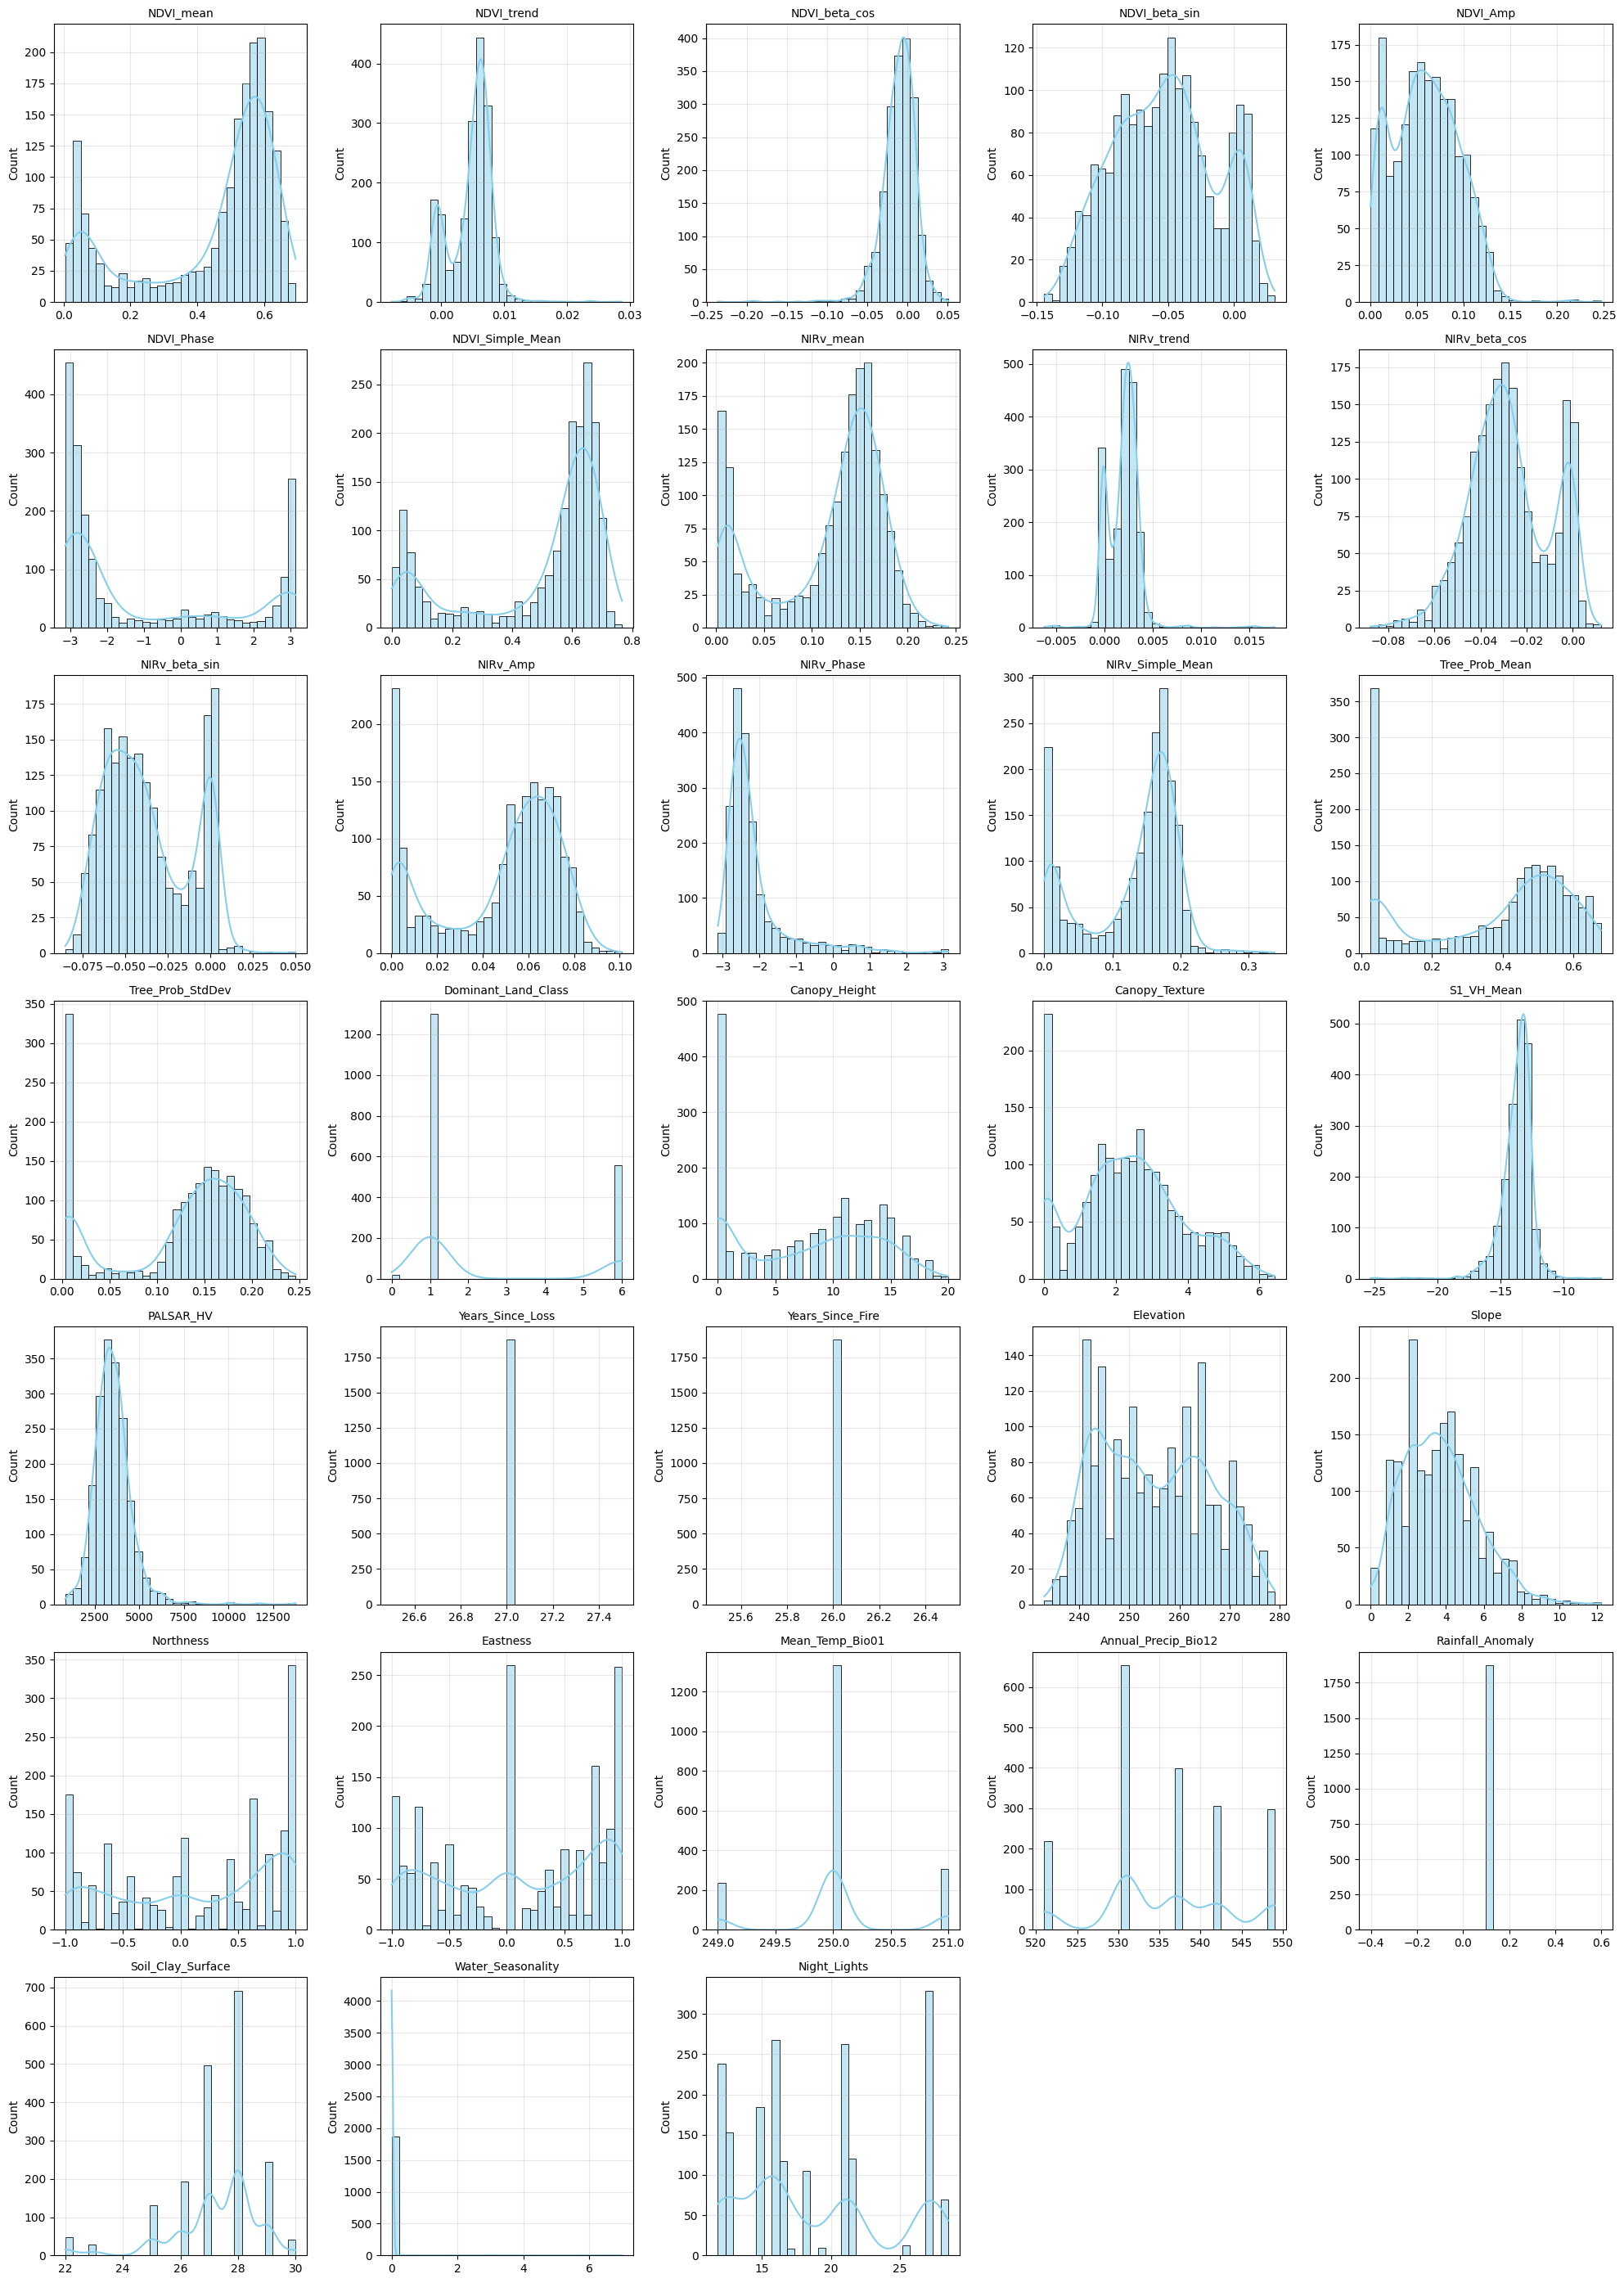

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ee
import math

SCALE = 10

print("Sampling 2,000 pixels to inspect distributions for ALL bands...")

try:

    band_names = master_stack.bandNames().getInfo()
    num_bands = len(band_names)
    print(f"Plotting histograms for {num_bands} features...")


    sample_data = master_stack.sample(
        region=roi,
        scale=SCALE,
        numPixels=2000,
        geometries=False
    ).getInfo()


    df_dist = pd.DataFrame([feat['properties'] for feat in sample_data['features']])


    cols = 5
    rows = math.ceil(num_bands / cols)


    plt.figure(figsize=(20, 4 * rows))

    for i, col in enumerate(band_names):
        if col in df_dist.columns:
            plt.subplot(rows, cols, i + 1)

            data = df_dist[col].dropna()

            if len(data) > 0:
                sns.histplot(data, kde=True, bins=30, color='skyblue', edgecolor='black')
                plt.title(col, fontsize=10)
                plt.xlabel('')
                plt.grid(True, alpha=0.3)
            else:
                plt.text(0.5, 0.5, "No Data", ha='center', va='center')
                plt.title(col)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error checking distributions: {e}")

In [ ]:

def preprocess_and_normalize(image, region, scale=10):





    useful_features = [

        'NDVI_mean', 'NDVI_Amp', 'NDVI_Phase', 'NDVI_trend',
        'NIRv_mean', 'NIRv_Amp', 'NIRv_Phase', 'NIRv_trend',


        'Canopy_Height', 'Canopy_Texture',
        'S1_VH_Mean', 'PALSAR_HV',


        'Tree_Prob_Mean', 'Tree_Prob_StdDev',


        'Elevation', 'Slope', 'Night_Lights',
        'Northness', 'Eastness'
    ]


    image_selected = image.select(useful_features)



    epsilon = 0.001

    log_bands = ['Canopy_Height', 'Canopy_Texture', 'Night_Lights', 'PALSAR_HV']


    for band in log_bands:

        img_log = image_selected.select(band).add(epsilon).log10().rename(f'{band}_Log')

        image_selected = image_selected.addBands(img_log, overwrite=True)





    stats = image_selected.reduceRegion(
        reducer=ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True),
        geometry=region,
        scale=scale,
        bestEffort=True,
        maxPixels=1e9
    )

    def normalize_band(band_name):
        band_name = ee.String(band_name)
        mean = ee.Number(stats.get(band_name.cat('_mean')))
        std = ee.Number(stats.get(band_name.cat('_stdDev')))

        return image_selected.select(band_name).subtract(mean).divide(std.max(0.0001)).rename(band_name)


    final_bands = image_selected.bandNames()
    normalized = ee.ImageCollection(final_bands.map(normalize_band)).toBands()


    return normalized.rename(final_bands)

print("Running Intelligent Pre-Processing (Dropping constants, Logging skewed data)...")
master_stack_norm = preprocess_and_normalize(master_stack, roi, SCALE)

print("Done! Valid Bands for Clustering:", master_stack_norm.bandNames().getInfo())

Running Intelligent Pre-Processing (Dropping constants, Logging skewed data)...
Done! Valid Bands for Clustering: ['NDVI_mean', 'NDVI_Amp', 'NDVI_Phase', 'NDVI_trend', 'NIRv_mean', 'NIRv_Amp', 'NIRv_Phase', 'NIRv_trend', 'Canopy_Height', 'Canopy_Texture', 'S1_VH_Mean', 'PALSAR_HV', 'Tree_Prob_Mean', 'Tree_Prob_StdDev', 'Elevation', 'Slope', 'Night_Lights', 'Northness', 'Eastness', 'Canopy_Height_Log', 'Canopy_Texture_Log', 'Night_Lights_Log', 'PALSAR_HV_Log']


In [ ]:
# @title
duplicates_to_drop = ['Canopy_Height', 'Canopy_Texture', 'Night_Lights', 'PALSAR_HV']

final_band_names = [b for b in master_stack_norm.bandNames().getInfo() if b not in duplicates_to_drop]

clustering_input = master_stack_norm.select(final_band_names)

print("--- Final Feature Set for Clustering ---")
print(f"Total Features: {len(final_band_names)}")
print(final_band_names)

--- Final Feature Set for Clustering ---
Total Features: 19
['NDVI_mean', 'NDVI_Amp', 'NDVI_Phase', 'NDVI_trend', 'NIRv_mean', 'NIRv_Amp', 'NIRv_Phase', 'NIRv_trend', 'S1_VH_Mean', 'Tree_Prob_Mean', 'Tree_Prob_StdDev', 'Elevation', 'Slope', 'Northness', 'Eastness', 'Canopy_Height_Log', 'Canopy_Texture_Log', 'Night_Lights_Log', 'PALSAR_HV_Log']


Sampling 5 RANDOM pixels from the NORMALIZED stack...

--- NORMALIZED FEATURE VECTORS (Expect values approx -3 to +3) ---


,0,1,2,3,4
Canopy_Height_Log,0.536079,-1.629982,-1.629982,-1.629982,0.646644
Canopy_Texture_Log,0.484897,-1.248023,0.081858,0.116111,0.550493
Eastness,-0.129685,1.191336,-0.129685,1.255030,1.191372
Elevation,0.648127,0.371445,1.109263,0.555900,-0.919735
NDVI_Amp,-0.266595,-1.153439,-1.512569,-1.113815,-0.018709
NDVI_Phase,-0.768784,0.216788,1.404088,-0.067712,1.515159
NDVI_mean,0.821261,-1.949703,-1.844660,-1.858999,0.518679
NDVI_trend,0.389853,-1.695926,-1.338571,-1.066333,0.532958
NIRv_Amp,0.314356,-1.656322,-1.717868,-1.513026,-0.159840
NIRv_Phase,-0.436402,1.442969,0.207916,0.740309,-0.607978



Plotting histograms to verify skewness correction...


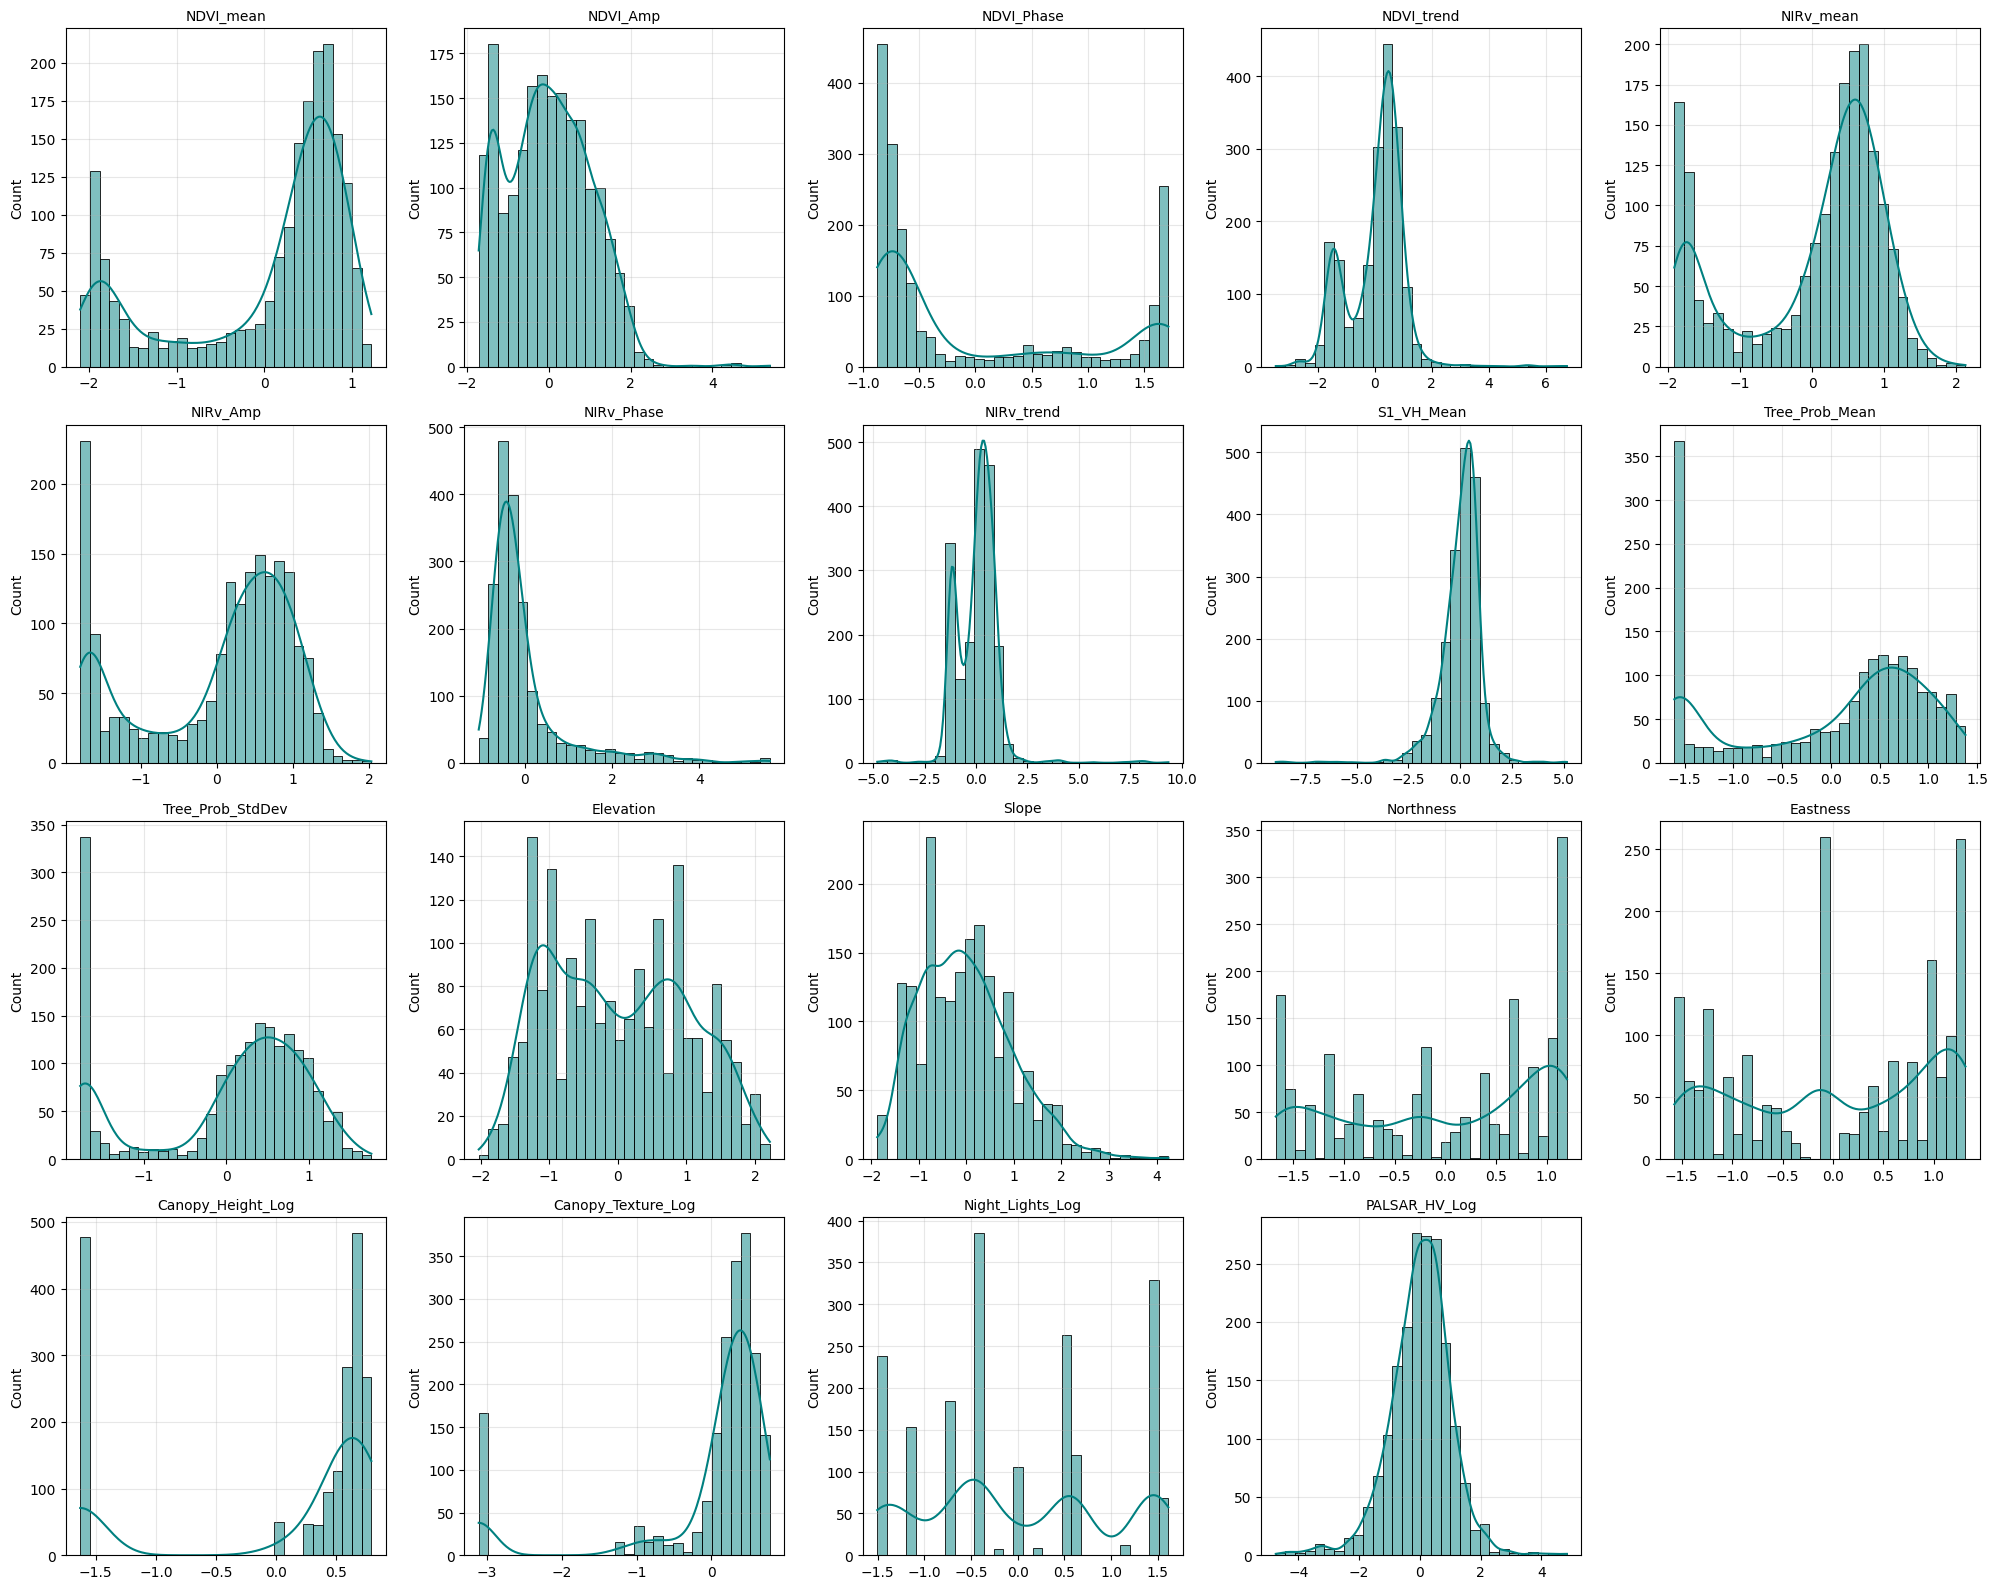

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ee
import math

print("Sampling 5 RANDOM pixels from the NORMALIZED stack...")
try:
    debug_norm = clustering_input.sample(
        region=roi,
        scale=SCALE,
        numPixels=5,
        geometries=False
    ).getInfo()

    if debug_norm['features']:
        df_norm_debug = pd.DataFrame([f['properties'] for f in debug_norm['features']])
        print("\n--- NORMALIZED FEATURE VECTORS (Expect values approx -3 to +3) ---")
        display(df_norm_debug.T.style.set_properties(**{'text-align': 'right'}))
    else:
        print("Warning: No pixels found for table inspection.")
except Exception as e:
    print(f"Table inspection failed: {e}")

print("\nPlotting histograms to verify skewness correction...")
try:

    sample_norm = clustering_input.sample(
        region=roi,
        scale=SCALE,
        numPixels=2000,
        geometries=False
    ).getInfo()

    df_norm_dist = pd.DataFrame([f['properties'] for f in sample_norm['features']])


    band_names_norm = clustering_input.bandNames().getInfo()
    num_bands = len(band_names_norm)
    cols = 5
    rows = math.ceil(num_bands / cols)

    plt.figure(figsize=(20, 4 * rows))

    for i, col in enumerate(band_names_norm):
        if col in df_norm_dist.columns:
            plt.subplot(rows, cols, i + 1)
            data = df_norm_dist[col].dropna()
            if len(data) > 0:
                sns.histplot(data, kde=True, bins=30, color='teal', edgecolor='black')
                plt.title(col, fontsize=10)
                plt.xlabel('')
                plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


except Exception as e:
    print(f"Plotting failed: {e}")

Fetching 5000 random pixels to calculate optimal 'k'...
Running sweep for k=[2, 3, 4, 5, 6, 7, 8, 9, 10] on 4720 pixels...


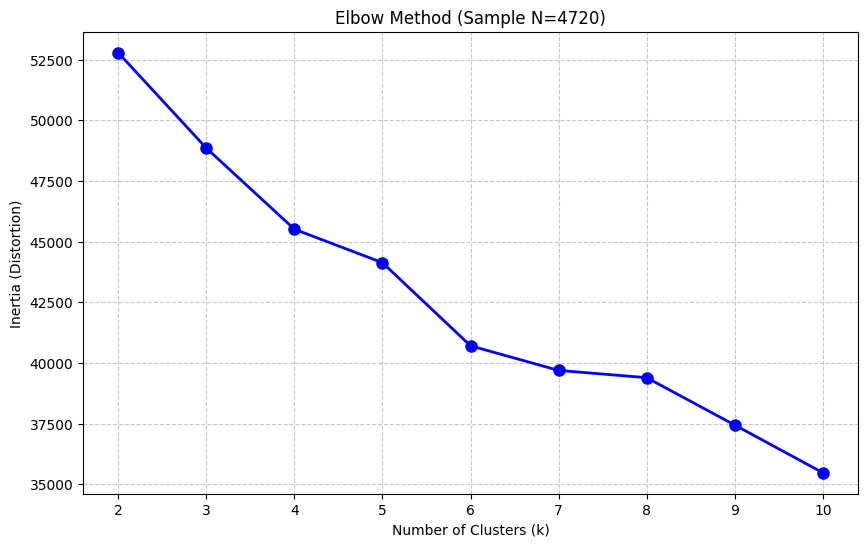

In [ ]:
# @title
import ee
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans


SAMPLE_SIZE = 5000
MAX_K = 10

print(f"Fetching {SAMPLE_SIZE} random pixels to calculate optimal 'k'...")

try:

    elbow_sample = clustering_input.sample(
        region=roi,
        scale=SCALE,
        numPixels=SAMPLE_SIZE,
        geometries=False
    ).getInfo()

    features = [f['properties'] for f in elbow_sample['features']]
    if not features:
        raise ValueError("No pixels returned. Check your ROI or Scale.")

    data_for_elbow = pd.DataFrame(features)


    data_for_elbow = data_for_elbow.select_dtypes(include=['number'])

    inertia = []
    K_RANGE = range(2, MAX_K + 1)

    print(f"Running sweep for k={list(K_RANGE)} on {len(data_for_elbow)} pixels...")

    for k in K_RANGE:

        model = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3, batch_size=1024)
        model.fit(data_for_elbow)
        inertia.append(model.inertia_)

    plt.figure(figsize=(10, 6))
    plt.plot(K_RANGE, inertia, 'bo-', linewidth=2, markersize=8)


    plt.title(f'Elbow Method (Sample N={len(data_for_elbow)})')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia (Distortion)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(K_RANGE)
    plt.show()


except Exception as e:
    print(f"Error: {e}")


Fetching 50000 pixels in 10 batches...
  - Requesting Batch 1/10...
  - Requesting Batch 2/10...
  - Requesting Batch 3/10...
  - Requesting Batch 4/10...
  - Requesting Batch 5/10...
  - Requesting Batch 6/10...
  - Requesting Batch 7/10...
  - Requesting Batch 8/10...
  - Requesting Batch 9/10...
  - Requesting Batch 10/10...
Success! Collected 47660 total pixels.
Running Elbow Sweep for k=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]...


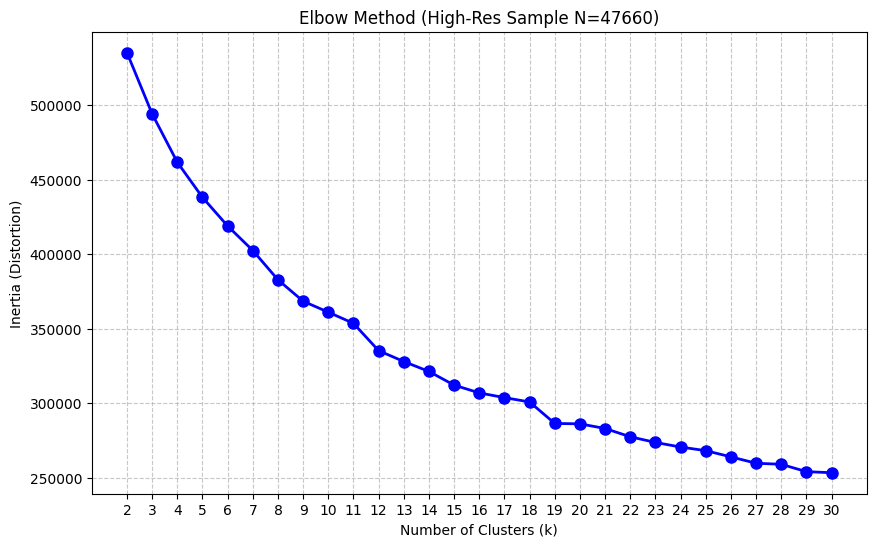

Interpretation:
If the curve is STILL smooth, it confirms that the forest transition is continuous.
In that case, stick with k=6 based on ecological classes.


In [ ]:
# @title
import ee
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans


TOTAL_PIXELS = 50000
BATCH_SIZE = 5000
NUM_BATCHES = TOTAL_PIXELS // BATCH_SIZE

print(f"Fetching {TOTAL_PIXELS} pixels in {NUM_BATCHES} batches...")

all_features = []

try:
    for i in range(NUM_BATCHES):
        print(f"  - Requesting Batch {i+1}/{NUM_BATCHES}...")


        batch_sample = clustering_input.sample(
            region=roi,
            scale=SCALE,
            numPixels=BATCH_SIZE,
            seed=i,
            geometries=False
        ).getInfo()


        batch_data = [f['properties'] for f in batch_sample['features']]
        all_features.extend(batch_data)

    print(f"Success! Collected {len(all_features)} total pixels.")


    data_for_elbow = pd.DataFrame(all_features)


    data_for_elbow = data_for_elbow.select_dtypes(include=['number'])


    inertia = []
    K_RANGE = range(2, 31)

    print(f"Running Elbow Sweep for k={list(K_RANGE)}...")

    for k in K_RANGE:

        model = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3, batch_size=1024)
        model.fit(data_for_elbow)
        inertia.append(model.inertia_)


    plt.figure(figsize=(10, 6))
    plt.plot(K_RANGE, inertia, 'bo-', linewidth=2, markersize=8)

    plt.title(f'Elbow Method (High-Res Sample N={len(data_for_elbow)})')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia (Distortion)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(K_RANGE)
    plt.show()

    print("Interpretation:")
    print("If the curve is STILL smooth, it confirms that the forest transition is continuous.")
    print("In that case, stick with k=6 based on ecological classes.")

except Exception as e:
    print(f"Error: {e}")

Running SNIC Segmentation only (Size=15)...
Fetching pixels for visualization...


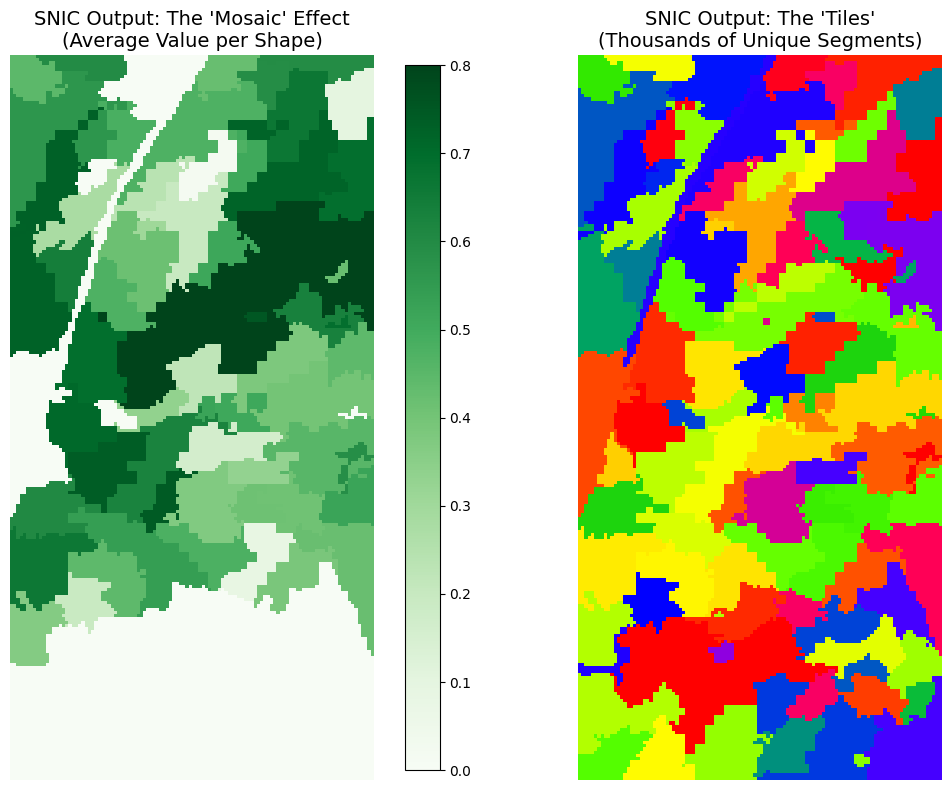

In [ ]:
# @title
import ee
import geemap
import matplotlib.pyplot as plt
import numpy as np

SNIC_SIZE = 15
COMPACTNESS = 0.5
print(f"Running SNIC Segmentation only (Size={SNIC_SIZE})...")

snic = ee.Algorithms.Image.Segmentation.SNIC(
    image=clustering_input,
    size=SNIC_SIZE,
    compactness=COMPACTNESS,
    connectivity=8,
    neighborhoodSize=2 * SNIC_SIZE,
    seeds=None
)

snic_result = snic.select(['NDVI_mean_mean', 'clusters'])

print("Fetching pixels for visualization...")

snic_pixels = geemap.ee_to_numpy(
    snic_result,
    region=roi,
    scale=SCALE
)

snic_pixels = snic_pixels.astype(float)
snic_pixels[snic_pixels == 0] = np.nan

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

ndvi_mean = snic_pixels[:, :, 0]
im1 = ax1.imshow(ndvi_mean, cmap='Greens', vmin=0, vmax=0.8)
ax1.set_title("SNIC Output: The 'Mosaic' Effect\n(Average Value per Shape)", fontsize=14)
ax1.axis('off')
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

cluster_ids = snic_pixels[:, :, 1]
im2 = ax2.imshow(cluster_ids, cmap='prism')
ax2.set_title("SNIC Output: The 'Tiles'\n(Thousands of Unique Segments)", fontsize=14)
ax2.axis('off')

plt.tight_layout()
plt.show()


1. Running OBIA Clustering (k=6)...
2. fetching pixels for static plot (this may take 10-15 seconds)...
3. Rendering Plot...


/tmp/ipykernel_802/299103129.py:77: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_clusters = plt.cm.get_cmap('Set1', OPTIMAL_K)


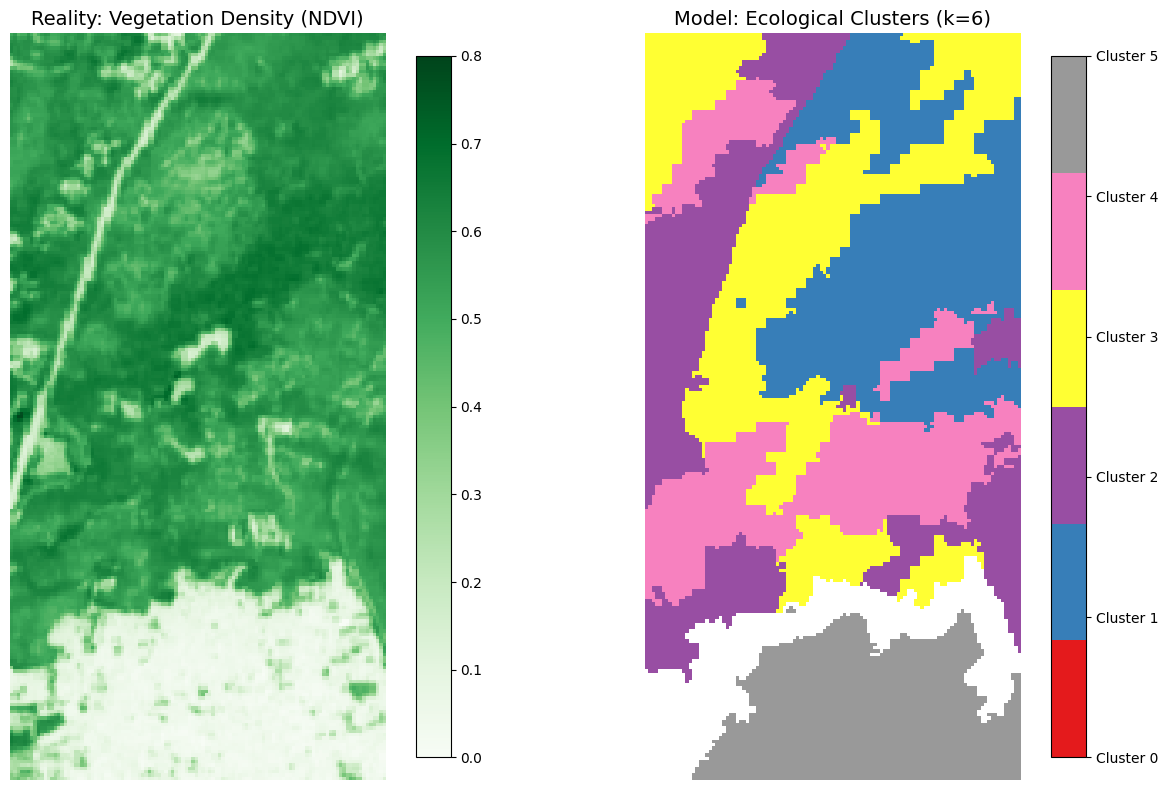

In [ ]:
# @title

import ee
import geemap
import matplotlib.pyplot as plt
import numpy as np


OPTIMAL_K = 6
SNIC_SIZE = 15
COMPACTNESS = 0.5

print(f"1. Running OBIA Clustering (k={OPTIMAL_K})...")


snic = ee.Algorithms.Image.Segmentation.SNIC(
    image=clustering_input,
    size=SNIC_SIZE,
    compactness=COMPACTNESS,
    connectivity=8,
    neighborhoodSize=2 * SNIC_SIZE,
    seeds=None
)


prediction_bands = snic.select('.*_mean')


training_objects = prediction_bands.sample(
    region=roi,
    scale=SCALE,
    numPixels=5000,
    geometries=True
)

clusterer_obia = ee.Clusterer.wekaKMeans(
    nClusters=OPTIMAL_K
).train(training_objects)


object_clusters = prediction_bands.cluster(clusterer_obia).rename('OBIA_Cluster')

print("2. fetching pixels for static plot (this may take 10-15 seconds)...")



comparison_image = master_stack.select('NDVI_mean').addBands(object_clusters)



rgb_img = geemap.ee_to_numpy(
    comparison_image,
    region=roi,
    scale=SCALE
)


rgb_img = rgb_img.astype(float)
rgb_img[rgb_img == 0] = np.nan

print("3. Rendering Plot...")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))



ndvi_data = rgb_img[:, :, 0]
im1 = ax1.imshow(ndvi_data, cmap='Greens', vmin=0, vmax=0.8)
ax1.set_title("Reality: Vegetation Density (NDVI)", fontsize=14)
ax1.axis('off')
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)


cluster_data = rgb_img[:, :, 1]

cmap_clusters = plt.cm.get_cmap('Set1', OPTIMAL_K)
im2 = ax2.imshow(cluster_data, cmap=cmap_clusters, vmin=0, vmax=OPTIMAL_K-1)
ax2.set_title(f"Model: Ecological Clusters (k={OPTIMAL_K})", fontsize=14)
ax2.axis('off')


cbar = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, ticks=range(OPTIMAL_K))
cbar.ax.set_yticklabels([f'Cluster {i}' for i in range(OPTIMAL_K)])

plt.tight_layout()
plt.show()



In [ ]:
# @title

import pandas as pd

print(f"Generating Cluster Report for k={OPTIMAL_K}...")




result_sample = object_clusters.addBands(prediction_bands).sample(
    region=roi,
    scale=SCALE,
    numPixels=5000,
    geometries=False
).getInfo()


df_stats = pd.DataFrame([f['properties'] for f in result_sample['features']])



cluster_stats = df_stats.groupby('OBIA_Cluster').mean().round(2)



key_cols = [
    'NDVI_mean_mean',
    'Canopy_Height_Log_mean',
    'S1_VH_Mean_mean',
    'PALSAR_HV_Log_mean',
    'Night_Lights_Log_mean',
    'Tree_Prob_Mean_mean'
]

available_cols = [c for c in key_cols if c in cluster_stats.columns]
display_stats = cluster_stats[available_cols]

print("\n--- CLUSTER STATISTICS (Interpret these to label your map) ---")
display_stats['Pixel_Count'] = df_stats['OBIA_Cluster'].value_counts()
display(display_stats.style.background_gradient(cmap='RdYlGn', axis=0))

Generating Cluster Report for k=6...

--- CLUSTER STATISTICS (Interpret these to label your map) ---


/tmp/ipykernel_802/1407278573.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  display_stats['Pixel_Count'] = df_stats['OBIA_Cluster'].value_counts()


,NDVI_mean_mean,Canopy_Height_Log_mean,S1_VH_Mean_mean,PALSAR_HV_Log_mean,Night_Lights_Log_mean,Tree_Prob_Mean_mean,Pixel_Count
OBIA_Cluster,,,,,,,
0,-1.330000,-1.440000,-0.010000,0.210000,1.080000,-1.480000,459
1,0.680000,0.620000,0.070000,0.040000,-0.950000,0.890000,1017
2,0.210000,0.020000,-0.540000,-0.400000,-0.010000,-0.200000,661
3,0.460000,0.530000,-0.010000,-0.110000,-0.090000,0.440000,1389
4,0.500000,0.500000,0.320000,0.120000,-0.340000,0.480000,790
5,-1.840000,-1.600000,0.020000,0.180000,1.290000,-1.580000,674


Running Statistical Validation...

--- GROUND TRUTH VALIDATION TABLE ---


,Spot,Satellite_Prediction
0,Spot 1 (Original),{'Dense Forest (Core)': 100.0}
1,Spot 2 (Peacock),"{'Bare Soil / Open Land': 0.8, 'High Biomass Forest': 59.9, 'Mixed Forest / Rough Edge': 39.2}"
2,Spot 3 (Investigation),{}



Fetching ROI pixels for static plot...


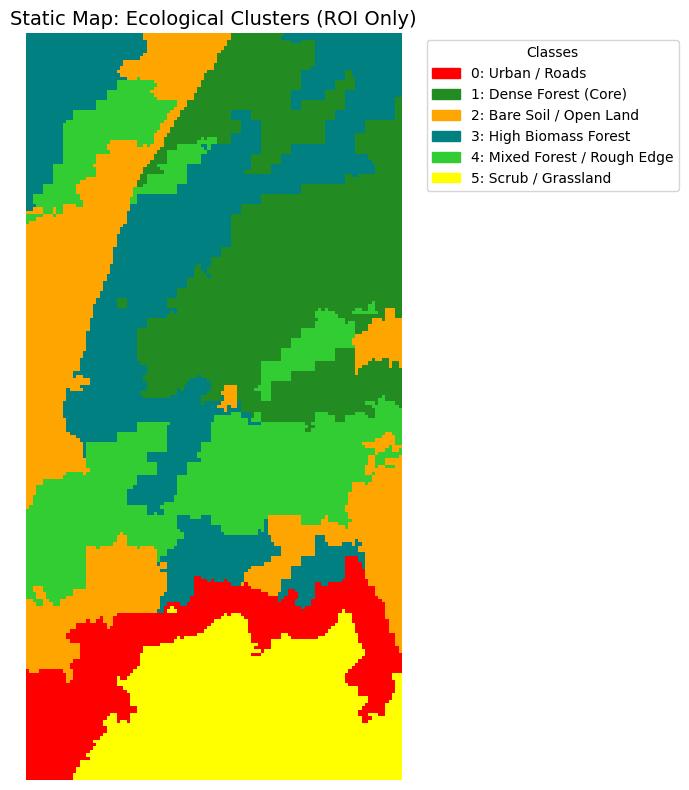

In [ ]:
# Cell 13: Ground Truth Validation (Strictly Static Output)
import ee
import pandas as pd
import geemap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- 1. SETUP ---
# Define Labels
cluster_labels = {
    0: "Urban / Roads",             # Red
    1: "Dense Forest (Core)",       # Dark Green
    2: "Bare Soil / Open Land",     # Orange
    3: "High Biomass Forest",       # Teal
    4: "Mixed Forest / Rough Edge", # Light Green
    5: "Scrub / Grassland"          # Yellow
}

# Define Drone Polygons (Coordinates from KML)
spot1_coords = [[77.175855, 28.533560], [77.177620, 28.533560],
                [77.177620, 28.532106], [77.175855, 28.532106],
                [77.175855, 28.533560]]
spot2_coords = [[77.173335, 28.529706], [77.175315, 28.529706],
                [77.175315, 28.528252], [77.173335, 28.528252],
                [77.173335, 28.529706]]
spot3_coords = [[77.185238, 28.531837], [77.186769, 28.531837],
                [77.186769, 28.530798], [77.185238, 28.530798],
                [77.185238, 28.531837]]

# Create Geometry Objects for Math
validation_spots = {
    "Spot 1 (Original)": ee.Geometry.Polygon(spot1_coords),
    "Spot 2 (Peacock)": ee.Geometry.Polygon(spot2_coords),
    "Spot 3 (Investigation)": ee.Geometry.Polygon(spot3_coords)
}

# --- 2. CALCULATE STATISTICS (THE MATH) ---
def get_class_composition(geometry, spot_name):
    hist = object_clusters.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=geometry,
        scale=SCALE,
        maxPixels=1e9
    ).getInfo()

    raw_counts = hist.get('OBIA_Cluster', {})
    total_pixels = sum(raw_counts.values())
    composition = {}

    if total_pixels > 0:
        for cluster_id, count in raw_counts.items():
            cluster_id = int(float(cluster_id))
            label = cluster_labels.get(cluster_id, f"Unknown ({cluster_id})")
            percent = (count / total_pixels) * 100
            composition[label] = round(percent, 1)

    return {"Spot": spot_name, "Satellite_Prediction": composition}

print("Running Statistical Validation...")
results = []
for name, geom in validation_spots.items():
    results.append(get_class_composition(geom, name))

# Display Table
df_results = pd.DataFrame(results)
pd.set_option('display.max_colwidth', None)
print("\n--- GROUND TRUTH VALIDATION TABLE ---")
display(df_results)

# --- 3. GENERATE STATIC IMAGE (THE VISUAL) ---
print("\nFetching ROI pixels for static plot...")

# Convert Earth Engine Image to Numpy Array (ROI ONLY)
rgb_img = geemap.ee_to_numpy(object_clusters, region=roi, scale=SCALE)
data = rgb_img.astype(float)[:, :, 0]

# Plotting
plt.figure(figsize=(10, 8))
hex_palette = ['#ff0000', '#228B22', '#FFA500', '#008080', '#32CD32', '#FFFF00']
cmap_final = plt.matplotlib.colors.ListedColormap(hex_palette)

plt.imshow(data, cmap=cmap_final, vmin=0, vmax=5)
plt.title("Static Map: Ecological Clusters (ROI Only)", fontsize=14)
plt.axis('off')

# Add Legend
patches = [mpatches.Patch(color=hex_palette[i], label=f"{i}: {label}")
           for i, label in cluster_labels.items()]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', title="Classes")

plt.tight_layout()
plt.show()

In [ ]:
!pip install rasterio

In [ ]:
# # Cell 15: Pixel-Perfect GeoTIFF Validation (Fixed for JSON Error)
# import rasterio
# from rasterio.warp import transform_bounds
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# import numpy as np
# import ee
# import geemap

# # --- 1. CONFIGURATION ---
# tif_path = '/content/drive/MyDrive/GeoSpatial_Data_for_Mapping/Spot_1_10-08-25.tif'

# hex_palette = ['#ff0000', '#228B22', '#FFA500', '#008080', '#32CD32', '#FFFF00']
# cluster_labels = {
#     0: "Urban", 1: "Dense Forest", 2: "Soil",
#     3: "High Biomass", 4: "Mixed/Trans", 5: "Scrub"
# }

# print(f"Reading GeoTIFF: {tif_path}...")
# try:
#     with rasterio.open(tif_path) as src:
#         drone_img = src.read()
#         src_crs = src.crs
#         src_bounds = src.bounds

#         print(f"Original Projection: {src_crs}")
#         print(f"Original Bounds (Meters): {src_bounds}")

#         # --- 2. PREPARE THE REGION ---
#         # Convert UTM Bounds -> WGS84 (Lat/Lon) for Earth Engine 'region'
#         wgs84_bounds = transform_bounds(src_crs, 'EPSG:4326',
#                                         src_bounds.left, src_bounds.bottom,
#                                         src_bounds.right, src_bounds.top)

#         roi_box = ee.Geometry.Rectangle([wgs84_bounds[0], wgs84_bounds[1],
#                                          wgs84_bounds[2], wgs84_bounds[3]])

#         # --- 3. FETCH ALIGNED DATA (The Fix) ---
#         print("Fetching aligned Satellite data...")

#         # Clip to the box
#         sat_clip = object_clusters.clip(roi_box)

#         # FIX: Explicitly reproject the IMAGE to match the Drone (UTM)
#         # This forces the pixels to line up with meters, not degrees
#         sat_reprojected = sat_clip.reproject(crs=str(src_crs), scale=10)

#         # Download without passing 'crs' argument (avoids the JSON error)
#         sat_pixels = geemap.ee_to_numpy(
#             sat_reprojected,
#             region=roi_box
#         )

#         sat_data = sat_pixels[:, :, 0].astype(float)
#         sat_data[sat_data == 0] = np.nan

#         # --- 4. THE OVERLAY PLOT ---
#         print("Generating Overlay...")
#         fig, ax = plt.subplots(figsize=(10, 10))

#         # Layer 1: Drone Image (Bottom) - Displayed in Meters
#         if drone_img.shape[0] >= 3:
#             display_img = np.moveaxis(drone_img[:3, :, :], 0, -1)
#             if display_img.max() > 1:
#                 display_img = display_img / 255.0
#             ax.imshow(display_img, extent=(src_bounds.left, src_bounds.right, src_bounds.bottom, src_bounds.top))
#         else:
#             ax.imshow(drone_img[0], cmap='gray', extent=(src_bounds.left, src_bounds.right, src_bounds.bottom, src_bounds.top))

#         # Layer 2: Satellite Classification (Top)
#         # Since we reprojected the image to UTM, it naturally aligns with the bounds
#         cmap_final = plt.matplotlib.colors.ListedColormap(hex_palette)

#         ax.imshow(sat_data, cmap=cmap_final, vmin=0, vmax=5, alpha=0.5,
#                    extent=(src_bounds.left, src_bounds.right, src_bounds.bottom, src_bounds.top),
#                    interpolation='nearest')

#         ax.set_title(f"Overlay Validation: Drone (Reality) vs. Satellite (Model)", fontsize=16, fontweight='bold')
#         ax.set_xlabel(f"Easting ({src_crs})")
#         ax.set_ylabel(f"Northing ({src_crs})")

#         patches = [mpatches.Patch(color=hex_palette[i], label=f"{i}: {label}")
#                    for i, label in cluster_labels.items()]
#         plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', title="Satellite Classes")

#         plt.tight_layout()
#         plt.show()

#         print("Validation Checklist:")
#         print("1. Find a distinct feature (like a big tree or a path) in the drone photo.")
#         print("2. Look at the colored block on top of it.")
#         print("3. Does the color match the logic? (Green=Tree, Red=Path)")

# except Exception as e:
#     print(f"An error occurred: {e}")

Reading GeoTIFF (Safe Mode): /content/drive/MyDrive/GeoSpatial_Data_for_Mapping/Spot_2_08-07-25.tif...
Original Size: 10203x11151
Loading at: 1020x1115 (to save RAM)
Fetching aligned Satellite data...
Generating Overlay...


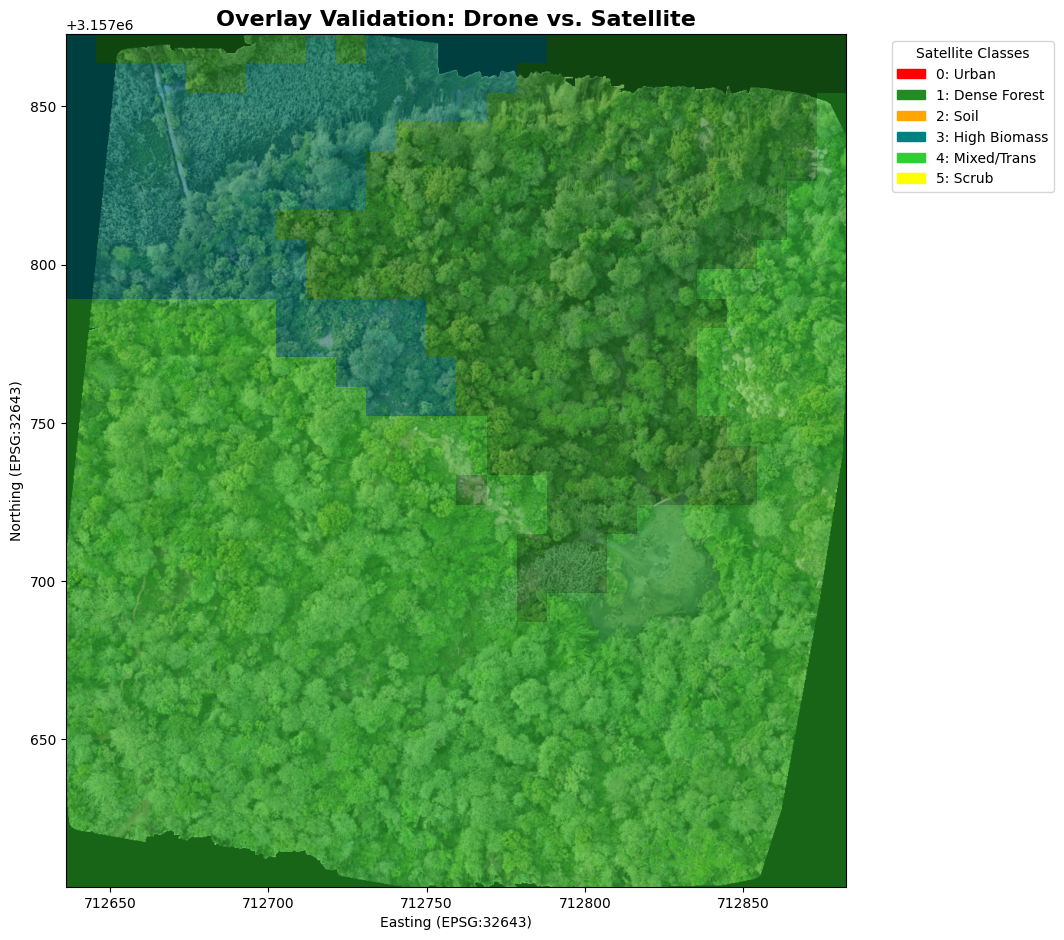

In [ ]:
# Cell 15: RAM-Safe Pixel-Perfect Validation (Downsampled)
import rasterio
from rasterio.warp import transform_bounds
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import ee
import geemap

# --- 1. CONFIGURATION ---
tif_path = '/content/drive/MyDrive/GeoSpatial_Data_for_Mapping/Spot_2_08-07-25.tif'
DOWNSAMPLE_FACTOR = 10  # Higher = Less RAM usage (1 = Full Res, 10 = 1/10th size)

hex_palette = ['#ff0000', '#228B22', '#FFA500', '#008080', '#32CD32', '#FFFF00']
cluster_labels = {
    0: "Urban", 1: "Dense Forest", 2: "Soil",
    3: "High Biomass", 4: "Mixed/Trans", 5: "Scrub"
}

print(f"Reading GeoTIFF (Safe Mode): {tif_path}...")
try:
    with rasterio.open(tif_path) as src:
        src_crs = src.crs
        src_bounds = src.bounds

        # --- MEMORY FIX: Downsample the image on load ---
        # We calculate a new smaller shape to fit in RAM
        new_height = int(src.height / DOWNSAMPLE_FACTOR)
        new_width = int(src.width / DOWNSAMPLE_FACTOR)

        print(f"Original Size: {src.width}x{src.height}")
        print(f"Loading at: {new_width}x{new_height} (to save RAM)")

        # Read only the smaller version
        drone_img = src.read(
            out_shape=(src.count, new_height, new_width),
            resampling=Resampling.bilinear
        )

        # --- PREPARE REGION ---
        wgs84_bounds = transform_bounds(src_crs, 'EPSG:4326',
                                        src_bounds.left, src_bounds.bottom,
                                        src_bounds.right, src_bounds.top)

        roi_box = ee.Geometry.Rectangle([wgs84_bounds[0], wgs84_bounds[1],
                                         wgs84_bounds[2], wgs84_bounds[3]])

        # --- 2. FETCH ALIGNED DATA ---
        print("Fetching aligned Satellite data...")

        # Clip & Reproject explicitly to match the Drone's projection
        sat_clip = object_clusters.clip(roi_box)
        sat_reprojected = sat_clip.reproject(crs=str(src_crs), scale=10)

        sat_pixels = geemap.ee_to_numpy(sat_reprojected, region=roi_box)
        sat_data = sat_pixels[:, :, 0].astype(float)
        sat_data[sat_data == 0] = np.nan

        # --- 3. THE OVERLAY PLOT ---
        print("Generating Overlay...")
        fig, ax = plt.subplots(figsize=(10, 10))

        # Layer 1: Drone Image (Bottom)
        if drone_img.shape[0] >= 3:
            display_img = np.moveaxis(drone_img[:3, :, :], 0, -1)
            if display_img.max() > 1:
                display_img = display_img / 255.0
            # Note: We use the ORIGINAL bounds for extent so it aligns with the map
            ax.imshow(display_img, extent=(src_bounds.left, src_bounds.right, src_bounds.bottom, src_bounds.top))
        else:
            ax.imshow(drone_img[0], cmap='gray', extent=(src_bounds.left, src_bounds.right, src_bounds.bottom, src_bounds.top))

        # Layer 2: Satellite Classification (Top)
        cmap_final = plt.matplotlib.colors.ListedColormap(hex_palette)

        ax.imshow(sat_data, cmap=cmap_final, vmin=0, vmax=5, alpha=0.5,
                   extent=(src_bounds.left, src_bounds.right, src_bounds.bottom, src_bounds.top),
                   interpolation='nearest')

        ax.set_title(f"Overlay Validation: Drone vs. Satellite", fontsize=16, fontweight='bold')
        ax.set_xlabel(f"Easting ({src_crs})")
        ax.set_ylabel(f"Northing ({src_crs})")

        patches = [mpatches.Patch(color=hex_palette[i], label=f"{i}: {label}")
                   for i, label in cluster_labels.items()]
        plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', title="Satellite Classes")

        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

Reconstructing dataset for analysis...
Features found: 19
Sampling pixels...
Training Random Forest to explain decisions...


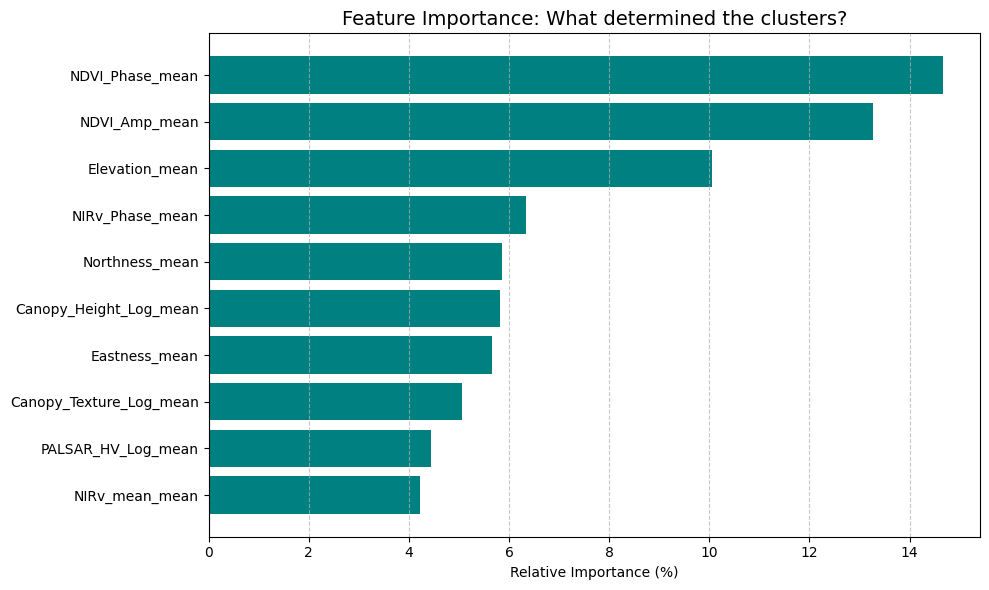


--- ANALYSIS ---
1. The Deciding Factor: NDVI_Phase_mean (14.7%)
   - This single variable is responsible for the biggest splits in your map.


In [ ]:
# Cell 16: Feature Importance Analysis (Corrected & Robust)
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

print("Reconstructing dataset for analysis...")

# --- 1. REJOIN FEATURES AND LABELS ---
# 'snic' contains the data (NDVI_mean_mean, Height, etc.)
# 'object_clusters' contains the result (Class 0, 1, 2...)
# We stack them together into one image
analysis_stack = snic.addBands(object_clusters)

# --- 2. DEFINE INPUTS ---
# We want to use all bands from SNIC as predictors
# But we must exclude 'clusters' (ID) and 'seeds' (Metadata)
input_features = snic.bandNames().removeAll(['clusters', 'seeds'])

# The property we want to explain
target_property = 'OBIA_Cluster'

print(f"Features found: {input_features.length().getInfo()}")

# --- 3. SAMPLE THE DATA ---
print("Sampling pixels...")
training_data = analysis_stack.sample(
    region=roi,
    scale=SCALE,
    numPixels=5000,
    geometries=False
)

# --- 4. TRAIN EXPLAINER MODEL ---
print("Training Random Forest to explain decisions...")
explainer_model = ee.Classifier.smileRandomForest(50).train(
    features=training_data,
    classProperty=target_property,
    inputProperties=input_features
)

# --- 5. EXTRACT & PLOT IMPORTANCE ---
importance_dict = explainer_model.explain().get('importance').getInfo()

# Create DataFrame
df_imp = pd.DataFrame(list(importance_dict.items()), columns=['Feature', 'Importance'])

# Normalize to Percentage
df_imp['Importance'] = (df_imp['Importance'] / df_imp['Importance'].sum()) * 100

# Sort and Top 10
df_imp = df_imp.sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(df_imp['Feature'], df_imp['Importance'], color='teal')
plt.xlabel('Relative Importance (%)')
plt.title('Feature Importance: What determined the clusters?', fontsize=14)
plt.gca().invert_yaxis() # Top feature at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- ANALYSIS ---")
top_feature = df_imp.iloc[0]['Feature']
top_score = round(df_imp.iloc[0]['Importance'], 1)
print(f"1. The Deciding Factor: {top_feature} ({top_score}%)")
print("   - This single variable is responsible for the biggest splits in your map.")

Running K-Means on Canopy Height ONLY...
Fetching pixels for Height Map...


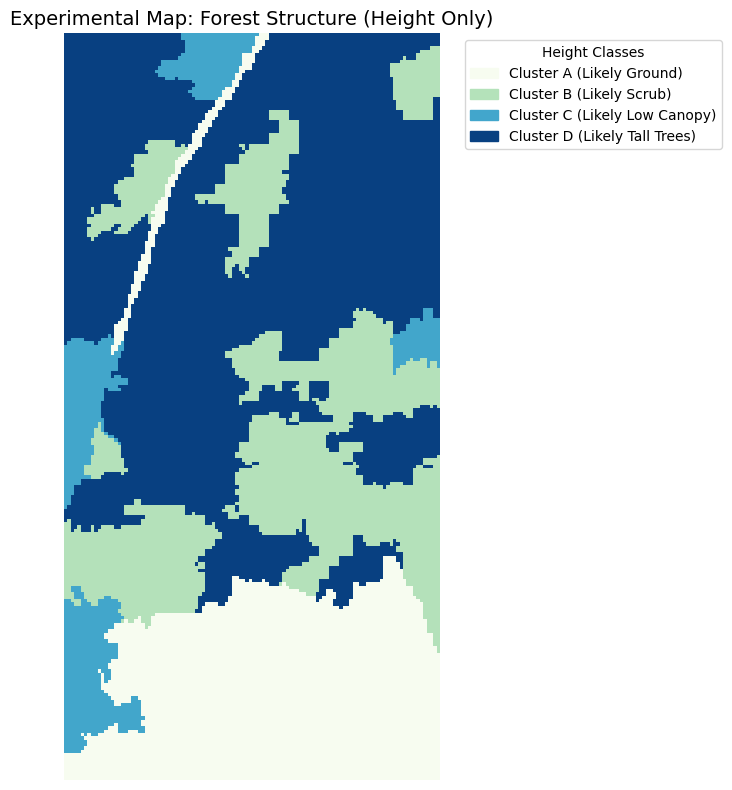

In [ ]:
# Cell 17: Experimental Clustering - Canopy Height Only
import ee
import geemap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("Running K-Means on Canopy Height ONLY...")

# --- 1. SELECT ONLY HEIGHT DATA ---
# We take the SNIC mean for height
height_input = snic.select(['Canopy_Height_Log_mean'])

# --- 2. TRAIN NEW CLUSTERER (Height Only) ---
# We use 4 clusters to capture: Ground, Scrub, Low Trees, Tall Trees
n_height_clusters = 4
training_dataset = height_input.sample(
    region=roi,
    scale=SCALE,
    numPixels=5000,
    geometries=True # We need geometries to display the training points if needed
)

# Train K-Means
height_clusterer = ee.Clusterer.wekaKMeans(n_height_clusters).train(training_dataset)

# Apply to the map
height_clusters = height_input.cluster(height_clusterer)

# --- 3. FETCH PIXELS FOR DISPLAY ---
print("Fetching pixels for Height Map...")
height_img = geemap.ee_to_numpy(height_clusters, region=roi, scale=SCALE)
height_data = height_img.astype(float)[:, :, 0]

# --- 4. PLOT ---
plt.figure(figsize=(10, 8))

# Define a Blue-Green palette (Light Blue=Low, Dark Green=High)
# We need to sort the colors so 0 is lowest and 3 is highest
# Note: K-Means assigns IDs randomly. We can't guarantee 0=Lowest without sorting.
# For visualization, we use a sequential colormap.
cmap_height = plt.get_cmap('GnBu', n_height_clusters)

plt.imshow(height_data, cmap=cmap_height)
plt.title("Experimental Map: Forest Structure (Height Only)", fontsize=14)
plt.axis('off')

# Create a Legend (Generic because we don't know exact meters)
patches = [
    mpatches.Patch(color=cmap_height(0), label="Cluster A (Likely Ground)"),
    mpatches.Patch(color=cmap_height(1), label="Cluster B (Likely Scrub)"),
    mpatches.Patch(color=cmap_height(2), label="Cluster C (Likely Low Canopy)"),
    mpatches.Patch(color=cmap_height(3), label="Cluster D (Likely Tall Trees)")
]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', title="Height Classes")

plt.tight_layout()
plt.show()

Reading Drone Image: /content/drive/MyDrive/GeoSpatial_Data_for_Mapping/Spot_1_10-08-25.tif...
Generating Overlay...


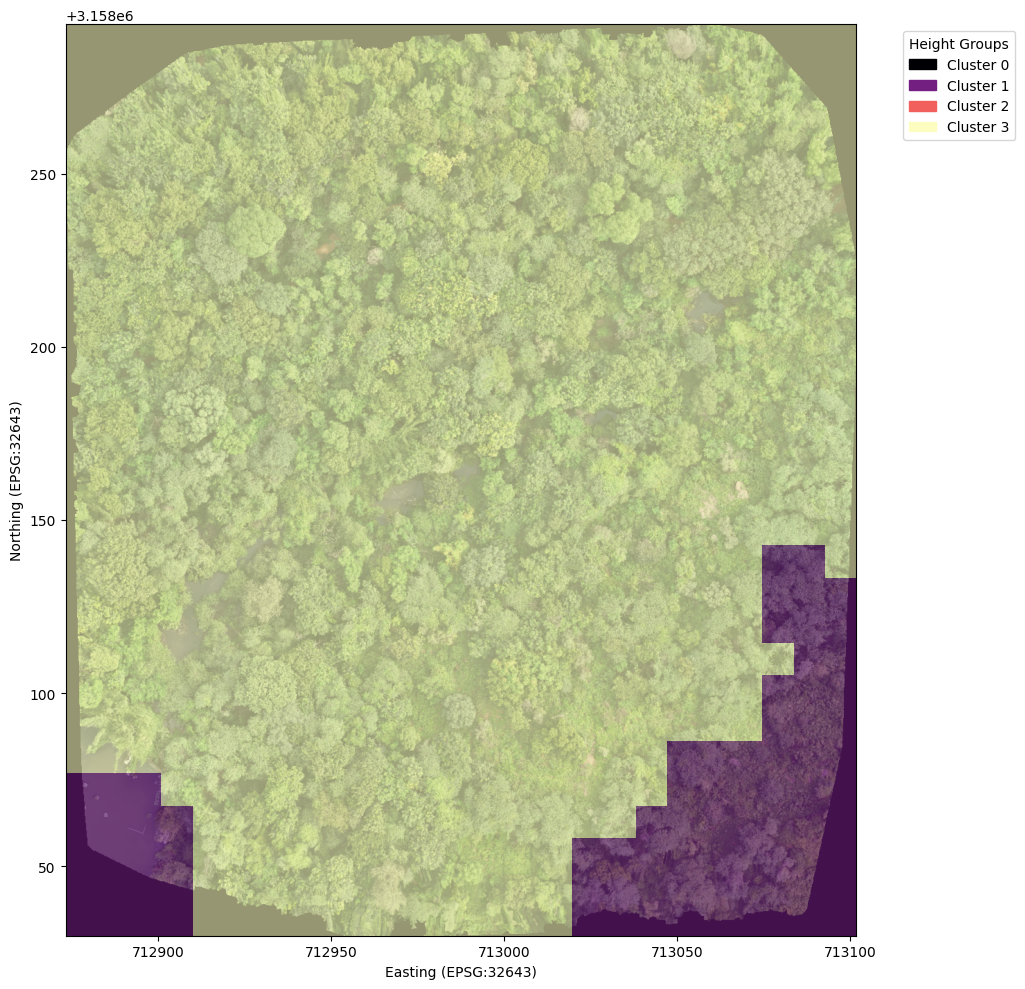

In [ ]:
# Cell 18: Height-Only Overlay (RAM-Safe)
import rasterio
from rasterio.warp import transform_bounds
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import ee
import geemap

# --- 1. CONFIGURATION ---
# We use the same file as before
tif_path = '/content/drive/MyDrive/GeoSpatial_Data_for_Mapping/Spot_1_10-08-25.tif'
DOWNSAMPLE_FACTOR = 10

# Use a distinct colormap for height (4 classes)
# We use 'magma' because it has high contrast (Black -> Purple -> Orange -> Yellow)
cmap_name = 'magma'

print(f"Reading Drone Image: {tif_path}...")
try:
    with rasterio.open(tif_path) as src:
        src_crs = src.crs
        src_bounds = src.bounds

        # Downsample for RAM safety
        new_height = int(src.height / DOWNSAMPLE_FACTOR)
        new_width = int(src.width / DOWNSAMPLE_FACTOR)

        drone_img = src.read(
            out_shape=(src.count, new_height, new_width),
            resampling=Resampling.bilinear
        )

        # Prepare Region for Earth Engine
        wgs84_bounds = transform_bounds(src_crs, 'EPSG:4326',
                                        src_bounds.left, src_bounds.bottom,
                                        src_bounds.right, src_bounds.top)

        roi_box = ee.Geometry.Rectangle([wgs84_bounds[0], wgs84_bounds[1],
                                         wgs84_bounds[2], wgs84_bounds[3]])


        # Clip & Reproject 'height_clusters' (from the previous cell)
        # Note: We rely on the variable 'height_clusters' existing in memory!
        sat_clip = height_clusters.clip(roi_box)
        sat_reprojected = sat_clip.reproject(crs=str(src_crs), scale=10)

        sat_pixels = geemap.ee_to_numpy(sat_reprojected, region=roi_box)
        sat_data = sat_pixels[:, :, 0].astype(float)
        sat_data[sat_data == 0] = np.nan

        # --- 3. PLOT ---
        print("Generating Overlay...")
        fig, ax = plt.subplots(figsize=(10, 10))

        # Bottom Layer: Drone
        if drone_img.shape[0] >= 3:
            display_img = np.moveaxis(drone_img[:3, :, :], 0, -1)
            if display_img.max() > 1:
                display_img = display_img / 255.0
            ax.imshow(display_img, extent=(src_bounds.left, src_bounds.right, src_bounds.bottom, src_bounds.top))
        else:
            ax.imshow(drone_img[0], cmap='gray', extent=(src_bounds.left, src_bounds.right, src_bounds.bottom, src_bounds.top))

        # Top Layer: Height Clusters
        # We use alpha=0.6 so the colors pop
        im = ax.imshow(sat_data, cmap=cmap_name, vmin=0, vmax=3, alpha=0.6,
                   extent=(src_bounds.left, src_bounds.right, src_bounds.bottom, src_bounds.top),
                   interpolation='nearest')

        ax.set_xlabel(f"Easting ({src_crs})")
        ax.set_ylabel(f"Northing ({src_crs})")

        # Custom Legend
        # Since K-Means IDs are random, we describe them by color
        # The user must look at the map to map Color -> Height
        import matplotlib as mpl
        colors = [mpl.colormaps[cmap_name](i/3) for i in range(4)]
        patches = [
            mpatches.Patch(color=colors[0], label="Cluster 0"),
            mpatches.Patch(color=colors[1], label="Cluster 1"),
            mpatches.Patch(color=colors[2], label="Cluster 2"),
            mpatches.Patch(color=colors[3], label="Cluster 3")
        ]
        plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', title="Height Groups")

        plt.tight_layout()
        plt.show()

except NameError:
    print("ERROR: 'height_clusters' is not defined. Please run the previous cell (Cell 17) first.")
except Exception as e:
    print(f"An error occurred: {e}")